In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load your clean, checkpointed data
print("Loading data...")
df = pl.read_parquet('../data/processed/train_data_imputed.parquet')

Loading data...


In [11]:
# 1. Class Imbalance
imbalance = df.group_by('target').len().with_columns(
    (pl.col('len') / df.height * 100).alias('percentage')
).to_pandas()

,target,class_name,len,percentage
0,1,Default,1377869,24.909721
1,0,Non-Default (Paid),4153582,75.090279


C:\Users\santo\AppData\Local\Temp\ipykernel_28400\1831976139.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


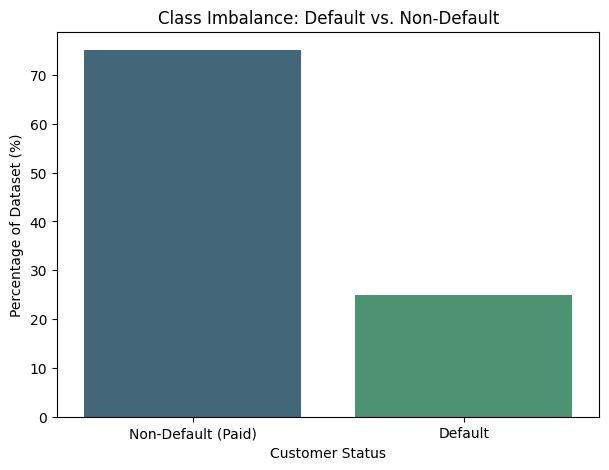

In [4]:
# 1. Create a new column mapping the integers to readable labels
imbalance['class_name'] = imbalance['target'].map({
    0: 'Non-Default (Paid)', 
    1: 'Default'
})

# 2. Display the updated, readable table
# Reordering columns to make it look clean
display_table = imbalance[['target', 'class_name', 'len', 'percentage']]
display(display_table)

# 3. Plot the graph using the new 'class_name' column for the x-axis
plt.figure(figsize=(7, 5))

# We use the class_name for x, and specify the order so Non-Default is on the left
sns.barplot(
    data=imbalance, 
    x='class_name', 
    y='percentage', 
    order=['Non-Default (Paid)', 'Default'],
    palette=['#3b6982', '#419d74'] # Colors similar to your original plot
)

plt.title("Class Imbalance: Default vs. Non-Default")
plt.xlabel("Customer Status")
plt.ylabel("Percentage of Dataset (%)")
plt.show()

In [7]:
# 1. Select the columns you want to summarize
# Let's include some of those extreme D columns we know have -999s
columns_to_view = [c for c in df.columns if c.startswith('P_') or c.startswith('D_5')]

# 2. Temporarily mask -999.0 as null ONLY for this specific calculation
safe_summary_df = df.select([
    # If the value is -999.0, treat it as None (null) for the math, otherwise keep the value
    pl.when(pl.col(c) == -999.0).then(None).otherwise(pl.col(c)).alias(c) 
    for c in columns_to_view if df.schema[c] in [pl.Float32, pl.Float64] # Ensure we only do this to floats
]).describe()

print("\n--- Numerical Feature Summaries (Excluding -999 Markers) ---")
display(safe_summary_df.to_pandas())


--- Numerical Feature Summaries (Excluding -999 Markers) ---


,statistic,P_2,D_50,D_51,D_52,P_3,D_53,D_54,D_55,D_56,D_58,D_59,P_4
0,count,5.531451e+06,2.389049e+06,5.531451e+06,5.531451e+06,5.531451e+06,1.446866e+06,5.531451e+06,5.531451e+06,2.540508e+06,5.531451e+06,5.531451e+06,5.531451e+06
1,null_count,0.000000e+00,3.142402e+06,0.000000e+00,0.000000e+00,0.000000e+00,4.084585e+06,0.000000e+00,0.000000e+00,2.990943e+06,0.000000e+00,0.000000e+00,0.000000e+00
2,mean,6.566495e-01,1.744347e-01,1.450790e-01,1.798601e-01,5.980625e-01,7.618342e-02,9.846466e-01,2.942009e-01,2.037094e-01,2.155312e-01,3.627309e-01,1.439271e-01
3,std,2.436547e-01,6.337476e-01,2.423309e-01,1.734191e-01,1.675643e-01,2.026926e-01,1.410806e-01,2.846480e-01,2.121586e-01,2.604405e-01,1.912699e-01,3.382721e-01
4,min,-4.589548e-01,-3.064871e+02,3.551497e-10,-7.083110e-03,-1.519690e+00,5.678129e-08,-2.005767e-03,2.353218e-08,-1.708915e-02,4.968945e-09,-1.024301e-01,2.668066e-09
5,25%,4.822539e-01,6.476120e-02,3.644930e-03,7.416942e-02,5.351584e-01,6.171482e-03,1.002342e+00,5.968657e-02,8.700980e-02,5.858127e-03,2.361245e-01,2.924060e-03
6,50%,6.942950e-01,1.094135e-01,7.282917e-03,1.444321e-01,6.149080e-01,1.337970e-02,1.004893e+00,1.816685e-01,1.494292e-01,1.065893e-01,3.784090e-01,5.848502e-03
7,75%,8.636537e-01,1.869698e-01,3.360340e-01,2.322985e-01,6.790191e-01,4.987856e-02,1.007447e+00,4.872088e-01,2.496251e-01,3.726996e-01,4.671832e-01,8.766024e-03
8,max,1.010000e+00,2.440427e+02,2.676606e+00,1.010000e+00,2.428051e+00,7.901939e+00,1.010000e+00,2.767759e+00,1.095651e+01,1.261945e+00,2.153332e+00,1.269390e+00


D_53 has a count of 1.44M and a null_count of 4.08M.

This perfectly matches the ~5.53 million total rows. It proves that Polars successfully ignored your -999 markers to calculate these statistics, leaving you with the pure, original data for those heavily missing columns.

Massive, Hidden Outliers (D_50 is wild)
The most important thing to check in a summary table is the difference between the percentiles (25%, 50%, 75%) and the min/max.

Look at D_50. The middle 50% of the data (between the 25th and 75th percentiles) sits tightly between 0.06 and 0.18.

However, its min is -306.4 and its max is 244.0!

The Insight: D_50 contains extreme outliers. If you were using a Logistic Regression or Neural Network, these outliers would completely break the model. Because you are using LightGBM, the tree will safely isolate these extreme values into their own branches.

The "Near-Constant" Feature (D_54)
Its mean is 0.98.

Its 25th percentile is 1.002.

Its max is 1.01.

The Insight: D_54 has almost zero variance. Practically every single customer in the dataset has a value around 1.0 for this feature. Features with practically no variance usually offer very little predictive power. LightGBM might end up ignoring this feature entirely during training.

The Payment Variables are Stable (P_2, P_3, P_4)
The variables starting with "P" (Payment variables) are remarkably clean.

They all have exactly 0 null_count. Every customer has this data.

P_2 (which is notoriously the most important feature in this entire competition) is nicely distributed. It ranges from roughly -0.45 to 1.01, with a clean median (50%) of 0.69.


--- Top 15 Features Correlated with Target (Excluding -999 Markers) ---


,correlation_with_target
P_2,-0.608091
D_48,0.541510
B_18,-0.487393
B_2,-0.482885
B_9,0.475858
D_75,0.457557
D_44,0.456542
B_33,-0.452741
D_55,0.451585
D_58,0.448642


C:\Users\santo\AppData\Local\Temp\ipykernel_28400\4133501599.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features['correlation_with_target'], y=top_features.index, palette='vlag')


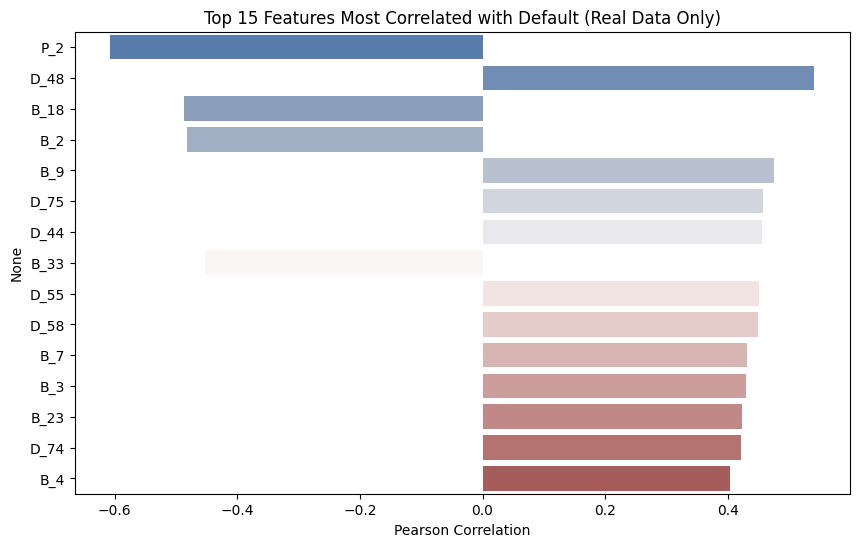

In [8]:
print("\n--- Top 15 Features Correlated with Target (Excluding -999 Markers) ---")

# Get numerical columns (excluding target)
num_types = [pl.Float32, pl.Float64, pl.Int32, pl.Int64]
num_cols = [c for c in df.columns if df.schema[c] in num_types and c != 'target']

# Calculate safe correlation: Mask -999.0 to None (null) so pl.corr ignores those rows
corr_exprs = [
    pl.corr(
        pl.when(pl.col(c) == -999.0).then(None).otherwise(pl.col(c)), 
        pl.col('target')
    ).alias(c) 
    for c in num_cols
]

# Execute the query and convert to Pandas for easy viewing
target_corrs = df.select(corr_exprs).to_pandas().T
target_corrs.columns = ['correlation_with_target']

# Sort to find the strongest positive and negative correlations
target_corrs = target_corrs.dropna().sort_values(by='correlation_with_target', key=abs, ascending=False)

top_features = target_corrs.head(15)
display(top_features)

# Plot the top correlations
plt.figure(figsize=(10, 6))
# Using a slightly updated palette for clarity
sns.barplot(x=top_features['correlation_with_target'], y=top_features.index, palette='vlag')
plt.title("Top 15 Features Most Correlated with Default (Real Data Only)")
plt.xlabel("Pearson Correlation")
plt.show()

P_2 (-0.608)
P_2 is a "Payment" variable, and a correlation of -0.608 is incredibly strong for real-world financial data.

What it means: Because the correlation is negative, as a customer's P_2 value increases, their likelihood of defaulting drastically decreases.

The Insight: This is universally recognized as the single most important feature in the entire Amex dataset. It likely represents a core payment health metric (like the percentage of the balance paid off). LightGBM model will almost certainly use P_2 for its very first, most critical tree splits.

The Red Flags (Positive Correlations)
Features like D_48 (+0.541), B_9 (+0.475), D_75 (+0.457), and D_44 (+0.456) are massive red flags.

What it means: The higher these numbers go, the higher the chance the customer will default.

The Insight: Notice that almost all of these start with D (Delinquency) or B (Balance). This perfectly aligns with real-world credit logic: as a customer's delinquency metrics (late days, missed payments) or total revolving balances go up, their risk profile skyrockets.

The Safety Nets (Negative Correlations)
Features like B_18 (-0.487), B_2 (-0.482), and B_33 (-0.452) are safety indicators alongside P_2.

What it means: Higher values here indicate a "safe" customer who is likely to pay their bill.

The Insight: While we don't know the exact definitions Amex uses, negative 'B' (Balance) features often represent things like "Available Credit Limit" or "Account Tenure." Higher limits or longer histories usually correlate with lower risk.

Plotting distributions for: ['P_2', 'D_48', 'B_18', 'B_2']


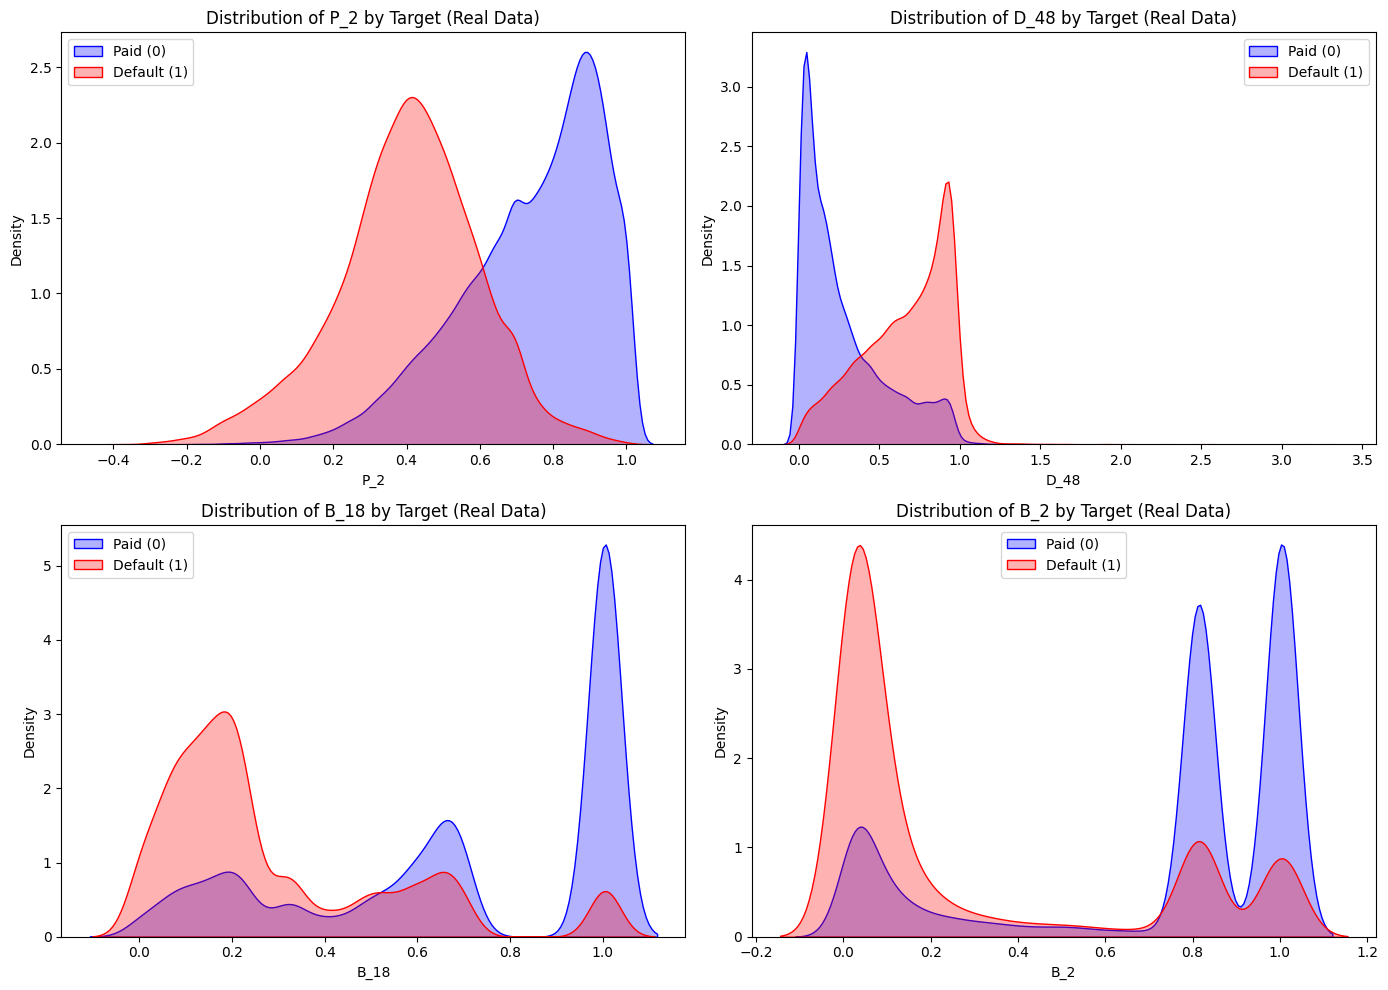

In [9]:
# 4. Feature Distributions (Separated by Target)
# Take the top 4 most correlated features from the previous step
features_to_plot = top_features.index[:4].tolist()

print(f"Plotting distributions for: {features_to_plot}")

# THE FIX: Mask -999.0 to null (None) so Seaborn ignores them
exprs = [
    pl.when(pl.col(c) == -999.0).then(None).otherwise(pl.col(c)).alias(c)
    for c in features_to_plot
] + [pl.col('target')]

# Extract safely masked sample
sample_df = df.select(exprs).sample(n=100000, seed=42).to_pandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Plot distribution for Paid (0)
    sns.kdeplot(data=sample_df[sample_df['target'] == 0], x=feature, fill=True, label='Paid (0)', ax=axes[i], color='blue', alpha=0.3)
    # Plot distribution for Default (1)
    sns.kdeplot(data=sample_df[sample_df['target'] == 1], x=feature, fill=True, label='Default (1)', ax=axes[i], color='red', alpha=0.3)
    
    axes[i].set_title(f"Distribution of {feature} by Target (Real Data)")
    axes[i].legend()

plt.tight_layout()
plt.show()

P_2 (Top Left) - The Master Predictor
The Paid Group (Blue): Heavily concentrated on the right side, peaking near 0.9.

The Default Group (Red): Concentrated in the middle, peaking near 0.4.

The Insight: This confirms our negative correlation. If a customer's P_2 score drops below 0.6, their risk of default skyrockets. LightGBM model will easily slice this graph right down the middle at 0.6 to separate the safe customers from the risky ones.

D_48 (Top Right) - The Delinquency Red Flag
The Paid Group (Blue): Almost completely clustered near 0.0. Safe customers simply do not have high values here.

The Default Group (Red): Distributed much higher, with a massive spike near 0.9.

The Insight: This is a classic "Delinquency" variable. If this value starts creeping up toward 1.0, it is a massive warning sign. The model will look for any value above ~0.3 as an indicator of default.

B_18 (Bottom Left) - The Safety Threshold
The Paid Group (Blue): Has a massive, undeniable spike exactly at 1.0.

The Default Group (Red): Mostly clustered down between 0.0 and 0.3.

The Insight: A value of 1.0 in B_18 acts like a "safety badge." If a customer has a 1.0, they are incredibly likely to pay their bill.

B_2 (Bottom Right) - The Binary Split
The Paid Group (Blue): Shows two massive peaks on the right side (around 0.8 and 1.0).

The Default Group (Red): Has one massive peak all the way on the left at 0.0.

The Insight: This is incredible feature separation. The model barely has to do any math here. It will just say: "If B_2 is near 0, predict Default. If B_2 is near 0.8 or 1.0, predict Paid."

Tree-based models work by drawing lines (splits) in the data. Because the data has such beautiful, distinct peaks with minimal overlap, LightGBM is going to have a very easy time drawing clean splits to achieve a high accuracy score.